In [1]:
import pandas as pd 
import numpy as np 
import warnings
warnings.filterwarnings('ignore')

In [12]:
voyage_lists = pd.read_csv('./data/cleaned_data/voyage_schedule.csv')
applications = pd.read_csv('./data/cleaned_data/applications.csv')
completions = pd.read_csv('./data/cleaned_data/completions.csv')
transactions = pd.read_csv('./data/cleaned_data/transactions.csv')

Empty DataFrame
Columns: [Unique ID, Transaction Date, Subscription Status, Payee Name, Payment Source, Product, Certificate Voyage, Payment Amount, Transaction Fee, Net Payment, Refund Amount, Credits Purchased]
Index: []


In [13]:
# Extract list of unique voyages from schedules
voyage_list = voyage_lists["Name"].dropna().unique()

# Merge data on Unique ID
merged_df = applications.merge(transactions, on="Unique ID", suffixes=('_applications' , '_transactions'))

merged_df = merged_df.merge(completions, on="Unique ID", suffixes=('' , '_completion'))

# Create voyage participation columns
for voyage in voyage_list:
    merged_df[voyage] = (merged_df["What is your Voyage?"] == voyage).astype(int)

# Drop redundant voyage column
merged_df.drop(columns=["What is your Voyage?"], inplace=True)

merged_df.to_csv('./data/cleaned_data/chingu_merged_df.csv', index = False)


In [14]:
merged_df.head()

,Unique ID,Timestamp,Subscription Status_applications,Subscription Status DT,Voyage Role,Gender,Goal,Source,Most Excited About,Country name (from Country),...,V18,V17,V16,V15,V14,V13,V12,V11,V10,V9
0,dadffe486c63fc05d8b3afee2c4dc132,2025-02-18 09:51:00,Active,2025-02-18,Scrum Master,FEMALE,GAIN EXPERIENCE,The Job Hackers,"2 - Having access to team project experiences,...",Canada,...,0,0,0,0,0,0,0,0,0,0
1,dadffe486c63fc05d8b3afee2c4dc132,2025-02-18 09:51:00,Active,2025-02-18,Scrum Master,FEMALE,GAIN EXPERIENCE,The Job Hackers,"2 - Having access to team project experiences,...",Canada,...,0,0,0,0,0,0,0,0,0,0
2,dadffe486c63fc05d8b3afee2c4dc132,2025-02-18 09:51:00,Active,2025-02-18,Scrum Master,FEMALE,GAIN EXPERIENCE,The Job Hackers,"2 - Having access to team project experiences,...",Canada,...,0,0,0,0,0,0,0,0,0,0
3,56a8ef8425ff0595bd660065cae07793,2025-01-03 10:21:00,Active,2025-01-03,Scrum Master,FEMALE,GAIN EXPERIENCE,PERSONAL NETWORK,"2 - Having access to team project experiences,...",United Kingdom,...,0,0,0,0,0,0,0,0,0,0
4,0a534d132b4dcf8e3b3dad5d766cac4b,2025-01-03 09:37:00,Active,2025-01-03,Developer,FEMALE,ACCELERATE LEARNING,LinkedIn,"2 - Having access to team project experiences,...",United States,...,0,0,0,0,0,0,0,0,0,0


In [12]:
merged_df.describe()


,Application Age in Days,Day-of-Week No,No. Voyages Started,Application Year,Credits Purchased,"On a scale of 0-10, how likely are you to recommend Chingu to a friend or colleagues?",V999,V55,V54,V53,...,V18,V17,V16,V15,V14,V13,V12,V11,V10,V9
count,11741.000000,11741.000000,11827.000000,11740.000000,2083.0,3523.000000,11839.0,11839.0,11839.0,11839.000000,...,11839.000000,11839.000000,11839.000000,11839.000000,11839.000000,11839.000000,11839.0,11839.0,11839.0,11839.0
mean,696.034495,4.072396,1.573011,2022.728450,0.0,9.368152,0.0,0.0,0.0,0.021792,...,0.000422,0.000591,0.000507,0.000169,0.001183,0.000507,0.0,0.0,0.0,0.0
std,416.140221,18.726732,3.250073,1.190598,0.0,1.257291,0.0,0.0,0.0,0.146011,...,0.020547,0.024310,0.022507,0.012997,0.034369,0.022507,0.0,0.0,0.0,0.0
min,0.000000,1.000000,0.000000,2019.000000,0.0,2.000000,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,391.000000,2.000000,0.000000,2022.000000,0.0,9.000000,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,656.000000,4.000000,0.000000,2023.000000,0.0,10.000000,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,934.000000,5.000000,2.000000,2024.000000,0.0,10.000000,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,1975.000000,2023.000000,16.000000,2025.000000,0.0,10.000000,0.0,0.0,0.0,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0,0.0,0.0


In [6]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11862 entries, 0 to 11861
Data columns (total 86 columns):
 #   Column                                                                                      Non-Null Count  Dtype  
---  ------                                                                                      --------------  -----  
 0   Unique ID                                                                                   11862 non-null  object 
 1   Timestamp                                                                                   11745 non-null  object 
 2   Subscription Status_applications                                                            11796 non-null  object 
 3   Subscription Status DT                                                                      11729 non-null  object 
 4   Voyage Role                                                                                 11862 non-null  object 
 5   Gender                                 

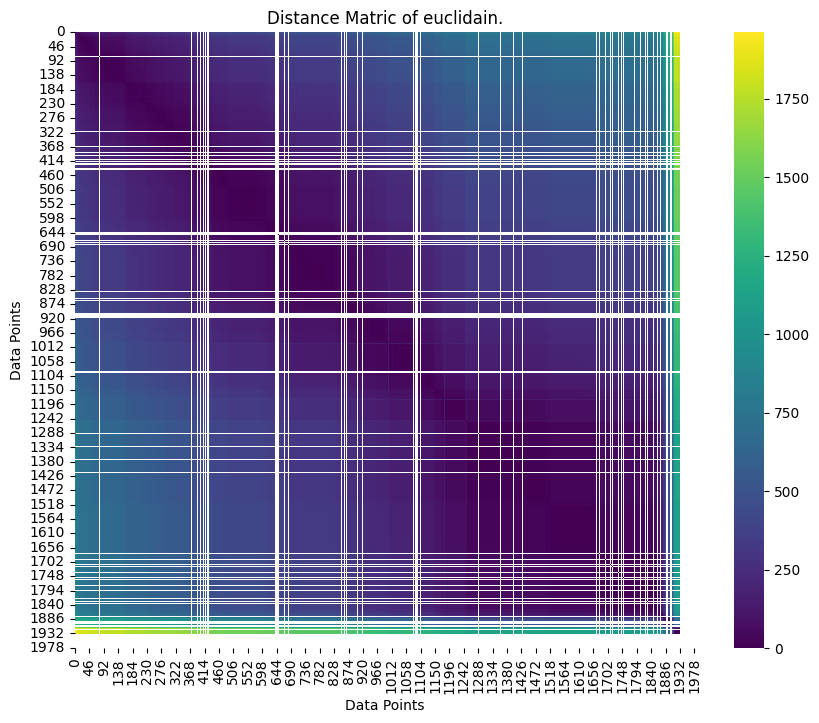

In [25]:
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import OneHotEncoder
categorical_fields = merged_df.select_dtypes(include=['object']).columns
encoder = OneHotEncoder(sparse_output = False, handle_unknown = 'ignore')
encoder_categorical = encoder.fit_transform(merged_df[categorical_fields])
# Convert to DataFrame
encoded_categorical_df = pd.DataFrame(encoder_categorical, 
                                      columns=encoder.get_feature_names_out(categorical_fields),
                                      index=merged_df.index)
# Combine numerical and encoded categorical data
final_encoded_df = pd.concat([merged_df.select_dtypes(include=['number']), encoded_categorical_df], axis=1)

# calculate distance matrix
distance_matrix = squareform(pdist(final_encoded_df, metric='euclidean'))
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(distance_matrix , cmap='viridis')
plt.title('Distance Matric of euclidain.')
plt.xlabel('Data Points')
plt.ylabel('Data Points')
plt.show()

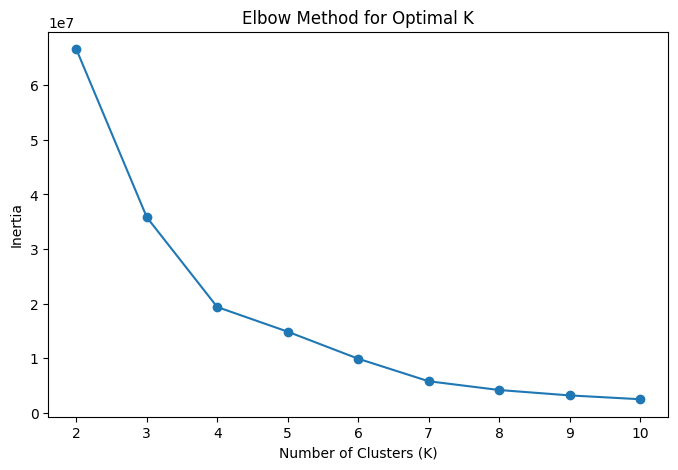

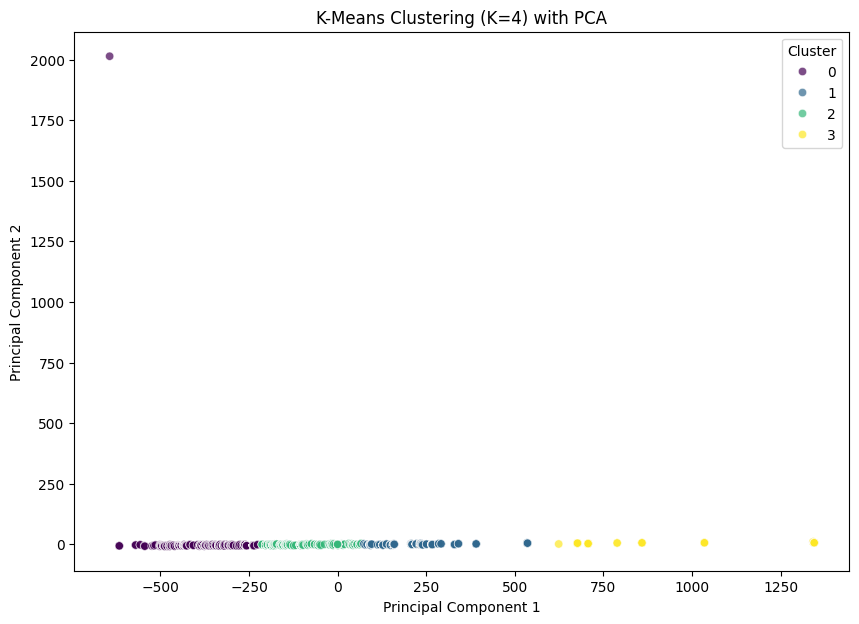

In [28]:
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Handle missing values in numerical columns by filling with the mean
num_imputer = SimpleImputer(strategy="mean")
numerical_data = merged_df.select_dtypes(include=['number'])
numerical_data_imputed = pd.DataFrame(num_imputer.fit_transform(numerical_data), 
                                      columns=numerical_data.columns, 
                                      index=merged_df.index)

# Handle missing values in categorical columns by filling with the mode (most frequent value)
cat_imputer = SimpleImputer(strategy="most_frequent")
categorical_data = merged_df[categorical_fields]
categorical_data_imputed = pd.DataFrame(cat_imputer.fit_transform(categorical_data), 
                                        columns=categorical_fields, 
                                        index=merged_df.index)

# Re-encode categorical columns after imputation
encoder_categorical = encoder.fit_transform(categorical_data_imputed)
encoded_categorical_df = pd.DataFrame(encoder_categorical, 
                                      columns=encoder.get_feature_names_out(categorical_fields),
                                      index=merged_df.index)

# Combine the cleaned numerical and categorical data
final_encoded_df = pd.concat([numerical_data_imputed, encoded_categorical_df], axis=1)

# Re-run K-Means clustering after handling NaN values
inertia = []
cluster_range = range(2, 11)  # Testing clusters from 2 to 10

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(final_encoded_df)
    inertia.append(kmeans.inertia_)

# Plot the Elbow method to determine optimal K
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, inertia, marker='o', linestyle='-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

# Choose an optimal number of clusters (K) based on the elbow method
optimal_k = 4  # Adjust based on the elbow point

# Apply K-Means clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(final_encoded_df)

# Add cluster labels to the dataset
merged_df["Cluster"] = cluster_labels

# Use PCA to reduce dimensionality for visualization
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(final_encoded_df)

# Create a scatter plot of the clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x=reduced_data[:, 0], y=reduced_data[:, 1], hue=cluster_labels, palette='viridis', alpha=0.7)
plt.title(f'K-Means Clustering (K={optimal_k}) with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title="Cluster")
plt.show()